# VAC-OPES simulation using "data rich" CVs

### Questions to answer:
1. This is the "best case scenario" for OPES.  How much sampling enhancement is acheived by sampling the WT distribution?  What are some measures of sampling enhancement?
2. Can we verify that the Boltzmann time expression is consisent with unbiased kinetics?  i.e. can we obtain the correct
$$
\mathbb{E}[\zeta(x_t)\zeta(x_{t+\tau})^\top]
$$

### Advantages over iterative OPES ("data poor")
1. $s(x)$ is trained on a large dataset
2. $s(x)$ and $w(s)$ are fixed throughout enhanced simulation
3. Therefore, $W_k \propto \mathrm{e}^{\beta w(s(x_k))}$ and bias shift not needed
4. Therefore, can measure enhancement as a time to reconstruct $p(s)$ ($F(s)$) compared to unbiased simulation
5. Can also see directly the effects of KDE hyperparameters on quality of $p(s)$ estimate.

# Overview
1. Load unbiased simulation data, SRV
2. KDE representation of unbiased $p(s)$
3. Construct OPES $w(s)$
4. Biased simulation using "simulation time"
5. Biased simulation using "Boltzmann time"

# 1. Load unbiased simulation data, SRV

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch

from src.data import simulation_data
from src.param import SimulationParameters

# from src.plots import plot_eigfuncs

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA, Torch version {torch.__version__}")
    print("-------------------------------------")
else:
    device = torch.device("cpu")
dtype = torch.float32

p = SimulationParameters(working_dir="data/unbiased")
sd = simulation_data(p)
net = sd.srv_net

# fig, axs = plt.subplots(2, 3, figsize=(8, 4), sharex=True, sharey=True)
# plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)
# fig.tight_layout()

Using CUDA, Torch version 2.1.2.post301
-------------------------------------
Loaded SimulationData object from data/unbiased with 350000 frames


# 2. Decide CV-space grids

In [ ]:
from src.hist2d import ranges_data, grids_ranges2d
from src.plots import plot_dihedrals_hist2d, plot_cvs_hist2d

ranges = ranges_data(sd.cvs, pad=0.25)
s1, s2 = grids_ranges2d(ranges)
print(
    f"Ranges on data: ({ranges[0][0]:.2f}, {ranges[0][1]:.2f}), ({ranges[1][0]:.2f}, {ranges[1][1]:.2f})"
)

# fig, axs = plt.subplots(1, 2, figsize=(7, 3))
# plot_dihedrals_hist2d(fig, axs[0], sd.dihedrals)
# plot_cvs_hist2d(fig, axs[1], s1, s2, sd.cvs)
# fig.tight_layout()

Ranges on data: (-1.62, 6.67), (-1.33, 2.16)


# 2. KDE, bias potential, FES
* `sd.fes` uses top formula for $F(s)$ below
* `sd.bias['fes']` uses bottom formula for $F(s)$ below

$$
\begin{align*}
w_n(s) &= kT(1-\gamma^{-1})\log\left[\frac{\widetilde{P}_n(s)}{Z_n} + \epsilon\right] \\
F_n(s) &= -kT \log\widetilde{P}_n(s) \\
       &= -(1 - \gamma^{-1})^{-1}~w_n(s) 
\end{align*}
$$

| Parameter | Variable | Value | Method, Notebook |
|-----------|----------|-------|----------|
| $T$  | `temperature` | 300 K | - |
| $w_1$, $w_2$ | `widths` | 0.02, 0.005 | `test-5g-kde-bandwidth` |
| $\gamma$ | `bias_factor` | 15 | `test-5i-bias-param` |
| $\epsilon$ | `dist_regularization` | $1\times 10^{-7}$ | `test-5i-bias-param` |
| $d_t$ | `dist_threshold` | 1.0 | `test-5j-bias-normfactor` |

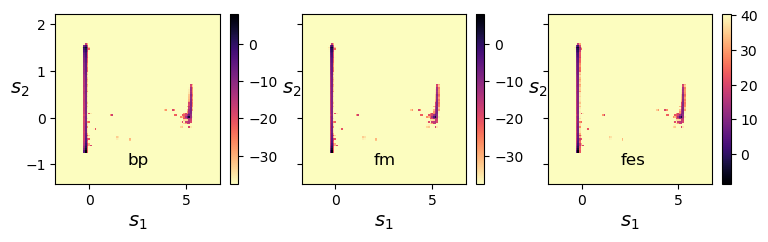

In [ ]:
from src.kde import kde_from_simdata_unweighted
from src.plots import plot_grid_fes, plot_surface

do_calc = False
if do_calc:
    widths = np.array([0.02, 0.005])
    ranges = [[-1.7, 6.7], [-1.4, 2.2]]
    s1, s2 = grids_ranges2d(ranges)
    kde = kde_from_simdata_unweighted(sd.cvs, widths)
    kde_c = kde.compress(dist_threshold=1.0).renormalize()
    sd.save_kde_fes_bias_data(p, s1, s2, widths, kde, kde_c)

s1, s2, widths, kde = sd.s1, sd.s2, sd.widths, sd.kde_c

# plot_grid_fes(s1, s2, sd.grid, sd.fes, figsize=(6, 5))

pos = (2, -1)
fig, axs = plt.subplots(1, 3, figsize=(9, 2.2), sharey=True)
for ax, label in zip(axs, sd.bias):
    cmap = "magma" if label == "fes" else "magma_r"
    cb = plot_surface(
        ax, s1, s2, sd.bias[label], cvs=True, cmap=cmap, label=label, pos=pos
    )
    fig.colorbar(cb)

# 3. Biased simulation using "simulation time"

In [ ]:
sd = simulation_data(p="data/datarich-opes/simulation-time")

Creating new directory data/datarich-opes/simulation-time
Creating new SimulationData object with no data at data/datarich-opes/simulation-time


In [ ]:
import openmm as mm
from openmm.app import Simulation, ForceField, PDBFile, DCDFile, HBonds
from openmmtorch import TorchForce

from src.util import create_system, bias_from_context
from src.util import assign_force_groups, check_force_group

pdb = PDBFile(p.pdb_file)
forcefield = ForceField("amber99sb.xml", "tip3p.xml")
system = create_system(forcefield, pdb.topology)

module = force_module(bp, kde, net, device=device, dtype=dtype)
file = sdo.working_dir / "force_module.pt"
torch.jit.script(module).save(file)
force = TorchForce(str(file))
force_group_id = system.addForce(force)
assign_force_groups(system)
check_force_group(system, force_group_id)

integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

In [ ]:
do_simulation = True
write_dcd = True

if do_simulation:
    simulation_biases = []
    simulation_weights = []
    simulation_features = []
    if write_dcd:
        dcdfile = open(sdo.files["dcdfile"], "wb")
        dcd = DCDFile(dcdfile, pdb.topology, p.timestep)

    for n in tqdm(range(p.num_frames)):
        simulation.step(p.timesteps_per_frame)
        bias = bias_from_context(simulation, force_group_id)
        weight = np.exp((bias - bias_shift) / bp.kT)
        state = simulation.context.getState(getPositions=True)
        r = state.getPositions()
        if write_dcd:
            dcd.writeModel(r, periodicBoxVectors=state.getPeriodicBoxVectors())
        positions = torch.tensor(r._value)
        simulation_features.append(module.featurize(positions).flatten().numpy())
        simulation_biases.append(bias)
        simulation_weights.append(weight)

    labels_objects = {
        "theta_grid": sdu.theta_grid,
        "final_positions": r,
        # 'features': np.array(simulation_features), # use dcd file instead
        "biases": np.array(simulation_biases),
        "weights": np.array(simulation_weights),
    }
    sdo.save_and_assign_objects(labels_objects)
    sdo.save_feature_data(recalculate=True, pdbfile=p.pdb_file)
    sdo.save_eigen_data(sdu.srv)

    if write_dcd:
        dcdfile.close()

# 4. Biased simulation using "Boltzmann time"

In [9]:
p.num_frames

10000

In [ ]:
sdo = simulation_data(p, subdir="boltzmann-time")
sdo.save_and_assign_objects({"bias_shift": bias_shift})
simulation.context.setPositions(pdb.positions)

do_simulation = True
write_dcd = True

if do_simulation:
    boltzmann_time = 0 * p.frametime
    simulation_biases = []
    simulation_weights = []
    simulation_features = []
    if write_dcd:
        dcdfile = open(sdo.files["dcdfile"], "wb")
        dcd = DCDFile(dcdfile, pdb.topology, p.timestep)

    for n in tqdm(range(p.num_frames)):
        lagtime_stop = (n + 1) * p.frametime

        while boltzmann_time < lagtime_stop:
            simulation.step(1)
            bias = bias_from_context(simulation, force_group_id)
            weight = np.exp((bias - bias_shift) / bp.kT)
            boltzmann_time += weight * p.timestep

        state = simulation.context.getState(getPositions=True)
        r = state.getPositions()
        if write_dcd:
            dcd.writeModel(r, periodicBoxVectors=state.getPeriodicBoxVectors())
        positions = torch.tensor(r._value)
        simulation_features.append(module.featurize(positions).flatten().numpy())
        simulation_biases.append(bias)
        simulation_weights.append(weight)

    labels_objects = {
        "theta_grid": sdu.theta_grid,
        "final_positions": r,
        # 'features': np.array(simulation_features), # use dcd file instead
        "biases": np.array(simulation_biases),
        "weights": np.array(simulation_weights),
    }
    sdo.save_and_assign_objects(labels_objects)
    sdo.save_feature_data(recalculate=True, pdbfile=p.pdb_file)
    sdo.save_eigen_data(sdu.srv)

    if write_dcd:
        dcdfile.close()

Loaded SimulationData object from data/datarich-opes/boltzmann-time with 1000 frames


  0%|          | 0/10000 [00:00<?, ?it/s]

writing data/datarich-opes/boltzmann-time/dihedrals.npy
writing data/datarich-opes/boltzmann-time/features.npy


In [11]:
weights = np.exp((sdo.biases - bias_shift) / bp.kT)
np.all(weights == sdo.weights)

True

In [12]:
features = np.array([f.flatten() for f in simulation_features])
np.all(features == sdo.features)

False